#**0. Importación de librerías**

In [ ]:
# --- Librerías base ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Preprocesamiento ---
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold

# --- Balanceo ---
from imblearn.over_sampling import SMOTENC

# --- Modelos supervisados ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# --- Modelos ensamble ---
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# --- Evaluación ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Análisis estadístico ---
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# **1. Carga de datos**

In [ ]:
df = pd.read_csv("datos_preparados_base (3).csv")

# Corregir tipos — al guardar/cargar CSV las categorías se pierden
cat_cols = [
    "Age Group", "Type of Admission", "APR DRG Code", "APR MDC Code",
    "APR Severity of Illness Code", "APR Risk of Mortality",
    "Payment Typology 1", "CCS_DX_Grupo", "CCS_PR_Grupo", "los_categoria"
]
for col in cat_cols:
    df[col] = df[col].astype("category")

print(f"Shape: {df.shape}")
print(f"\nTipos de datos:")
df.info()

Shape: (9994, 10)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Age Group                     9994 non-null   category
 1   Type of Admission             9994 non-null   category
 2   APR DRG Code                  9994 non-null   category
 3   APR MDC Code                  9994 non-null   category
 4   APR Severity of Illness Code  9994 non-null   category
 5   APR Risk of Mortality         9994 non-null   category
 6   Payment Typology 1            9994 non-null   category
 7   los_categoria                 9994 non-null   category
 8   CCS_DX_Grupo                  9994 non-null   category
 9   CCS_PR_Grupo                  9994 non-null   category
dtypes: category(10)
memory usage: 121.3 KB


In [ ]:
df.head()

,Age Group,Type of Admission,APR DRG Code,APR MDC Code,APR Severity of Illness Code,APR Risk of Mortality,Payment Typology 1,los_categoria,CCS_DX_Grupo,CCS_PR_Grupo
0,18 to 29,Urgent,566,14,2,Minor,Miscellaneous/Other,Corta,Embarazo_parto,Sin_procedimiento
1,50 to 69,Emergency,420,10,2,Moderate,Blue Cross/Blue Shield,Corta,Endocrinas_metabolicas,Sin_procedimiento
2,70 or Older,Emergency,173,5,1,Minor,Medicare,Corta,Circulatorio,Digestivo
3,18 to 29,Emergency,566,14,2,Minor,Medicare,Corta,Embarazo_parto,Sin_procedimiento
4,70 or Older,Emergency,351,8,2,Moderate,Medicare,Corta,Musculoesqueletico,Musculoesqueletico


# **2. Verificar si balanceo es necesario en target**

=== Distribución variable objetivo ===
los_categoria
Corta    5573
Media    2637
Larga    1784
Name: count, dtype: int64

los_categoria
Corta    0.558
Media    0.264
Larga    0.179
Name: proportion, dtype: float64


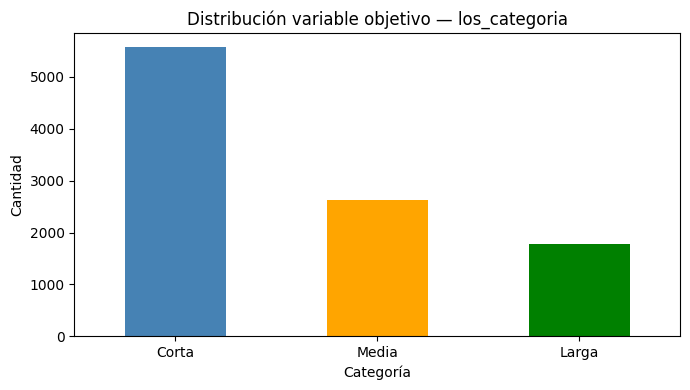

In [ ]:
objetivo = "los_categoria"

print("=== Distribución variable objetivo ===")
print(df[objetivo].value_counts())
print()
print(df[objetivo].value_counts(normalize=True).round(3))

df[objetivo].value_counts().plot(
    kind="bar",
    color=["steelblue", "orange", "green"],
    figsize=(7, 4)
)
plt.title("Distribución variable objetivo — los_categoria")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **3. División 70 / 30**

In [ ]:
X = df.drop(columns=[objetivo])
Y = df[objetivo]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

print(f"Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nDistribución train antes del balanceo:")
print(Y_train.value_counts())

Train: 6995 registros (70.0%)
Test:  2999 registros (30.0%)

Distribución train antes del balanceo:
los_categoria
Corta    3900
Media    1846
Larga    1249
Name: count, dtype: int64


# **4. Balanceo en 70%**

In [ ]:
from imblearn.over_sampling import SMOTEN

cat_indices = list(range(X_train.shape[1]))

smote = SMOTEN(
    sampling_strategy={"Larga": 1950},
    k_neighbors=5,
    random_state=42
)

X_bal, Y_bal = smote.fit_resample(X_train, Y_train)

data_train = pd.DataFrame(columns=X_bal.columns.values, data=X_bal)
data_train[objetivo] = Y_bal

print(f"\nShape train balanceado: {data_train.shape}")


Shape train balanceado: (7696, 10)


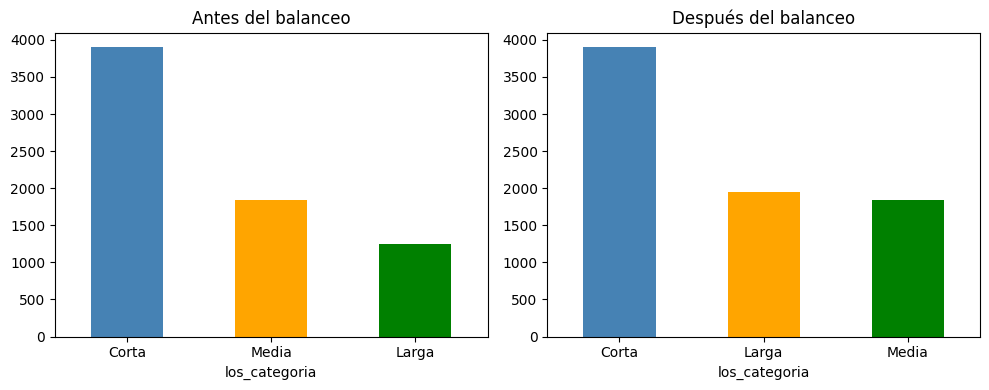

In [ ]:
# Visualización antes y después del balanceo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
Y_train.value_counts().plot(kind="bar", ax=axes[0], color=["steelblue","orange","green"])
axes[0].set_title("Antes del balanceo")
axes[0].tick_params(axis="x", rotation=0)
data_train[objetivo].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue","orange","green"])
axes[1].set_title("Después del balanceo")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# **5. Transfromaciones (dummies + label encoder)**

In [ ]:
#Dummies para todas las predictoras categóricas
todas_categoricas = [
    "Age Group", "Type of Admission", "APR DRG Code", "APR MDC Code",
    "APR Severity of Illness Code", "APR Risk of Mortality",
    "Payment Typology 1", "CCS_DX_Grupo", "CCS_PR_Grupo"
]

data_train = pd.get_dummies(data_train, columns=todas_categoricas, drop_first=False, dtype=int)

# Aplicar mismas dummies al test y alinear columnas
X_test_dum = pd.get_dummies(X_test, columns=todas_categoricas, drop_first=False, dtype=int)
X_test_dum = X_test_dum.reindex(columns=[c for c in data_train.columns if c != objetivo], fill_value=0)

print(f"Shape train tras dummies: {data_train.shape}")
print(f"Shape test tras dummies: {X_test_dum.shape}")

Shape train tras dummies: (7696, 382)
Shape test tras dummies: (2999, 381)


In [ ]:
#Label encoder:
le = LabelEncoder()
data_train[objetivo] = le.fit_transform(data_train[objetivo])
Y_test_enc = le.transform(Y_test)

print(f"Clases: {list(le.classes_)}")
print(f"Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Clases: ['Corta', 'Larga', 'Media']
Encoding: {'Corta': np.int64(0), 'Larga': np.int64(1), 'Media': np.int64(2)}


In [ ]:
X_train_dum = data_train.drop(columns=[objetivo])
Y_train_enc = data_train[objetivo]

print(f"X_train: {X_train_dum.shape}")
print(f"X_test:  {X_test_dum.shape}")

X_train: (7696, 381)
X_test:  (2999, 381)


# **6. Validación Cruzada**

In [ ]:
# DataFrame para comparar todos los modelos
comparacion_CV = pd.DataFrame()

# Métricas — macro porque es multiclase
scoring = ('f1_macro', 'accuracy', 'precision_macro', 'recall_macro')

# StratifiedKFold obligatorio en clasificación
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Configuración lista:")
print(f"  Folds: 5")
print(f"  Métricas: {scoring}")
print(f"  X_train shape: {X_train_dum.shape}")
print(f"  Clases: {list(le.classes_)}")

Configuración lista:
  Folds: 5
  Métricas: ('f1_macro', 'accuracy', 'precision_macro', 'recall_macro')
  X_train shape: (7696, 381)
  Clases: ['Corta', 'Larga', 'Media']


# **7. Modelos supervisados**

In [ ]:
import pickle
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay

todos_los_modelos = {}
resultados_cv = {}

**7.1 Decision Tree**

DECISION TREE

[Validación Cruzada]
Val F1-macro  : 0.5862 ± 0.0098
Train F1-macro: 0.6277
Val Accuracy  : 0.6106
Val Precision : 0.5891
Val Recall    : 0.5963

[Evaluación en Test 30%]
Test F1-macro : 0.5562
Test Accuracy : 0.5999

              precision    recall  f1-score   support

       Corta       0.78      0.69      0.73      1673
       Larga       0.50      0.59      0.54       535
       Media       0.38      0.43      0.40       791

    accuracy                           0.60      2999
   macro avg       0.55      0.57      0.56      2999
weighted avg       0.62      0.60      0.61      2999



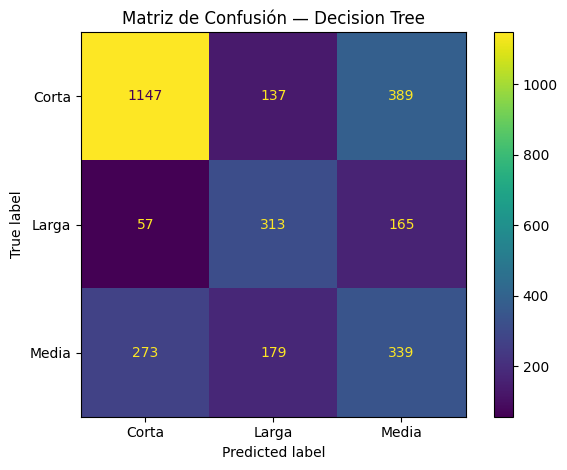

In [ ]:
# ============================================================
# MODELO 1 — DECISION TREE
# ============================================================
print("="*60)
print("DECISION TREE")
print("="*60)

model_tree = DecisionTreeClassifier(
    criterion='gini', max_depth=15, min_samples_leaf=15,
    min_samples_split=30, class_weight='balanced', random_state=42
)

cv_res = cross_validate(model_tree, X_train_dum, Y_train_enc, cv=cv, scoring=scoring, return_train_score=True)

todos_los_modelos['Tree'] = model_tree
resultados_cv['Tree'] = {
    'val_f1':        cv_res['test_f1_macro'].mean(),
    'val_f1_std':    cv_res['test_f1_macro'].std(),
    'val_accuracy':  cv_res['test_accuracy'].mean(),
    'val_precision': cv_res['test_precision_macro'].mean(),
    'val_recall':    cv_res['test_recall_macro'].mean(),
    'train_f1':      cv_res['train_f1_macro'].mean(),
    'f1_por_fold':   cv_res['test_f1_macro']
}

print(f"\n[Validación Cruzada]")
print(f"Val F1-macro  : {resultados_cv['Tree']['val_f1']:.4f} ± {resultados_cv['Tree']['val_f1_std']:.4f}")
print(f"Train F1-macro: {resultados_cv['Tree']['train_f1']:.4f}")
print(f"Val Accuracy  : {resultados_cv['Tree']['val_accuracy']:.4f}")
print(f"Val Precision : {resultados_cv['Tree']['val_precision']:.4f}")
print(f"Val Recall    : {resultados_cv['Tree']['val_recall']:.4f}")

model_tree.fit(X_train_dum, Y_train_enc)
Y_pred_tree = model_tree.predict(X_test_dum)

print(f"\n[Evaluación en Test 30%]")
print(f"Test F1-macro : {f1_score(Y_test_enc, Y_pred_tree, average='macro'):.4f}")
print(f"Test Accuracy : {accuracy_score(Y_test_enc, Y_pred_tree):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_tree, target_names=le.classes_)}")

ConfusionMatrixDisplay.from_predictions(Y_test_enc, Y_pred_tree, display_labels=le.classes_)
plt.title("Matriz de Confusión — Decision Tree")
plt.tight_layout()
plt.show()

comparacion_CV['Tree'] = cv_res['test_f1_macro']

**7.2 Regresión Logística**

REGRESIÓN LOGÍSTICA

[Validación Cruzada]
Val F1-macro  : 0.6242 ± 0.0076
Train F1-macro: 0.6645
Val Accuracy  : 0.6485
Val Precision : 0.6230
Val Recall    : 0.6333

[Evaluación en Test 30%]
Test F1-macro : 0.5908
Test Accuracy : 0.6282

              precision    recall  f1-score   support

       Corta       0.82      0.69      0.75      1673
       Larga       0.52      0.64      0.57       535
       Media       0.41      0.49      0.45       791

    accuracy                           0.63      2999
   macro avg       0.59      0.61      0.59      2999
weighted avg       0.66      0.63      0.64      2999



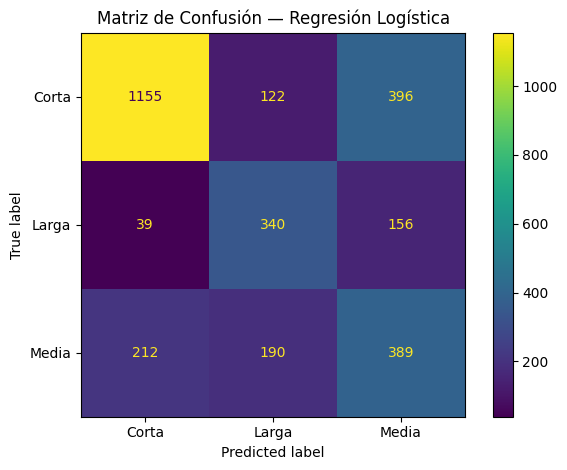

In [ ]:
# ============================================================
# MODELO 2 — REGRESIÓN LOGÍSTICA
# ============================================================
print("="*60)
print("REGRESIÓN LOGÍSTICA")
print("="*60)

model_lr = LogisticRegression(
    C=0.5, solver='lbfgs', multi_class='multinomial',
    max_iter=1000, class_weight='balanced', random_state=42
)

cv_res = cross_validate(model_lr, X_train_dum, Y_train_enc, cv=cv, scoring=scoring, return_train_score=True)

todos_los_modelos['LR'] = model_lr
resultados_cv['LR'] = {
    'val_f1':        cv_res['test_f1_macro'].mean(),
    'val_f1_std':    cv_res['test_f1_macro'].std(),
    'val_accuracy':  cv_res['test_accuracy'].mean(),
    'val_precision': cv_res['test_precision_macro'].mean(),
    'val_recall':    cv_res['test_recall_macro'].mean(),
    'train_f1':      cv_res['train_f1_macro'].mean(),
    'f1_por_fold':   cv_res['test_f1_macro']
}

print(f"\n[Validación Cruzada]")
print(f"Val F1-macro  : {resultados_cv['LR']['val_f1']:.4f} ± {resultados_cv['LR']['val_f1_std']:.4f}")
print(f"Train F1-macro: {resultados_cv['LR']['train_f1']:.4f}")
print(f"Val Accuracy  : {resultados_cv['LR']['val_accuracy']:.4f}")
print(f"Val Precision : {resultados_cv['LR']['val_precision']:.4f}")
print(f"Val Recall    : {resultados_cv['LR']['val_recall']:.4f}")

model_lr.fit(X_train_dum, Y_train_enc)
Y_pred_lr = model_lr.predict(X_test_dum)

print(f"\n[Evaluación en Test 30%]")
print(f"Test F1-macro : {f1_score(Y_test_enc, Y_pred_lr, average='macro'):.4f}")
print(f"Test Accuracy : {accuracy_score(Y_test_enc, Y_pred_lr):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_lr, target_names=le.classes_)}")

ConfusionMatrixDisplay.from_predictions(Y_test_enc, Y_pred_lr, display_labels=le.classes_)
plt.title("Matriz de Confusión — Regresión Logística")
plt.tight_layout()
plt.show()

comparacion_CV['LR'] = cv_res['test_f1_macro']

**7.3 Red neuronal**

RED NEURONAL (MLP)

[Validación Cruzada]
Val F1-macro  : 0.6043 ± 0.0100
Train F1-macro: 0.6460
Val Accuracy  : 0.6733
Val Precision : 0.6185
Val Recall    : 0.6098

[Evaluación en Test 30%]
Test F1-macro : 0.5792
Test Accuracy : 0.6666

              precision    recall  f1-score   support

       Corta       0.75      0.86      0.80      1673
       Larga       0.53      0.67      0.59       535
       Media       0.50      0.26      0.34       791

    accuracy                           0.67      2999
   macro avg       0.60      0.60      0.58      2999
weighted avg       0.65      0.67      0.64      2999



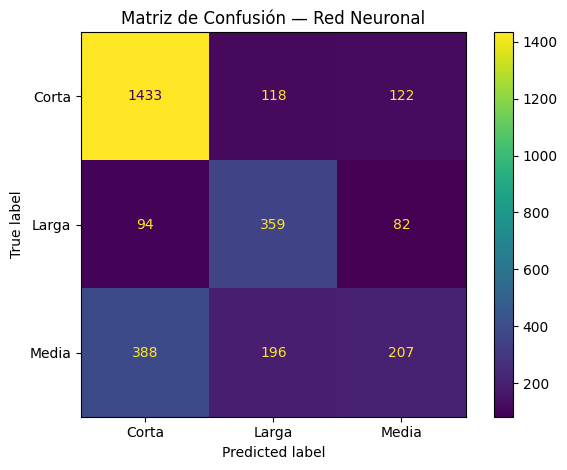

In [ ]:
# ============================================================
# MODELO 3 — RED NEURONAL (MLP)
# ============================================================
print("="*60)
print("RED NEURONAL (MLP)")
print("="*60)

model_rn = MLPClassifier(
    hidden_layer_sizes=(30,), activation='relu', alpha=1.0,
    learning_rate='adaptive', learning_rate_init=0.001,
    momentum=0.9, max_iter=500, random_state=42
)

cv_res = cross_validate(model_rn, X_train_dum, Y_train_enc, cv=cv, scoring=scoring, return_train_score=True)

todos_los_modelos['NN'] = model_rn
resultados_cv['NN'] = {
    'val_f1':        cv_res['test_f1_macro'].mean(),
    'val_f1_std':    cv_res['test_f1_macro'].std(),
    'val_accuracy':  cv_res['test_accuracy'].mean(),
    'val_precision': cv_res['test_precision_macro'].mean(),
    'val_recall':    cv_res['test_recall_macro'].mean(),
    'train_f1':      cv_res['train_f1_macro'].mean(),
    'f1_por_fold':   cv_res['test_f1_macro']
}

print(f"\n[Validación Cruzada]")
print(f"Val F1-macro  : {resultados_cv['NN']['val_f1']:.4f} ± {resultados_cv['NN']['val_f1_std']:.4f}")
print(f"Train F1-macro: {resultados_cv['NN']['train_f1']:.4f}")
print(f"Val Accuracy  : {resultados_cv['NN']['val_accuracy']:.4f}")
print(f"Val Precision : {resultados_cv['NN']['val_precision']:.4f}")
print(f"Val Recall    : {resultados_cv['NN']['val_recall']:.4f}")

model_rn.fit(X_train_dum, Y_train_enc)
Y_pred_rn = model_rn.predict(X_test_dum)

print(f"\n[Evaluación en Test 30%]")
print(f"Test F1-macro : {f1_score(Y_test_enc, Y_pred_rn, average='macro'):.4f}")
print(f"Test Accuracy : {accuracy_score(Y_test_enc, Y_pred_rn):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_rn, target_names=le.classes_)}")

ConfusionMatrixDisplay.from_predictions(Y_test_enc, Y_pred_rn, display_labels=le.classes_)
plt.title("Matriz de Confusión — Red Neuronal")
plt.tight_layout()
plt.show()

comparacion_CV['NN'] = cv_res['test_f1_macro']

**7.4 SVM**

SVM

[Validación Cruzada]
Val F1-macro  : 0.6216 ± 0.0068
Train F1-macro: 0.6644
Val Accuracy  : 0.6420
Val Precision : 0.6245
Val Recall    : 0.6288

[Evaluación en Test 30%]
Test F1-macro : 0.5875
Test Accuracy : 0.6212

              precision    recall  f1-score   support

       Corta       0.82      0.67      0.74      1673
       Larga       0.53      0.59      0.56       535
       Media       0.41      0.54      0.46       791

    accuracy                           0.62      2999
   macro avg       0.59      0.60      0.59      2999
weighted avg       0.66      0.62      0.63      2999



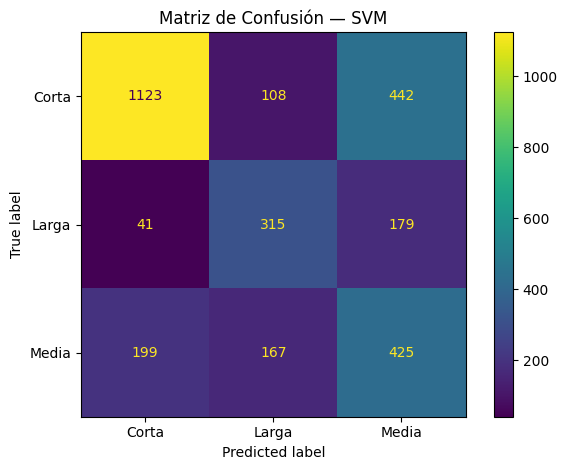

In [ ]:
# ============================================================
# MODELO 4 — SVM
# ============================================================
print("="*60)
print("SVM")
print("="*60)

model_svm = SVC(
    kernel='linear', C=0.5, gamma='scale',
    class_weight='balanced', random_state=42
)

cv_res = cross_validate(model_svm, X_train_dum, Y_train_enc, cv=cv, scoring=scoring, return_train_score=True)

todos_los_modelos['SVM'] = model_svm
resultados_cv['SVM'] = {
    'val_f1':        cv_res['test_f1_macro'].mean(),
    'val_f1_std':    cv_res['test_f1_macro'].std(),
    'val_accuracy':  cv_res['test_accuracy'].mean(),
    'val_precision': cv_res['test_precision_macro'].mean(),
    'val_recall':    cv_res['test_recall_macro'].mean(),
    'train_f1':      cv_res['train_f1_macro'].mean(),
    'f1_por_fold':   cv_res['test_f1_macro']
}

print(f"\n[Validación Cruzada]")
print(f"Val F1-macro  : {resultados_cv['SVM']['val_f1']:.4f} ± {resultados_cv['SVM']['val_f1_std']:.4f}")
print(f"Train F1-macro: {resultados_cv['SVM']['train_f1']:.4f}")
print(f"Val Accuracy  : {resultados_cv['SVM']['val_accuracy']:.4f}")
print(f"Val Precision : {resultados_cv['SVM']['val_precision']:.4f}")
print(f"Val Recall    : {resultados_cv['SVM']['val_recall']:.4f}")

model_svm.fit(X_train_dum, Y_train_enc)
Y_pred_svm = model_svm.predict(X_test_dum)

print(f"\n[Evaluación en Test 30%]")
print(f"Test F1-macro : {f1_score(Y_test_enc, Y_pred_svm, average='macro'):.4f}")
print(f"Test Accuracy : {accuracy_score(Y_test_enc, Y_pred_svm):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_svm, target_names=le.classes_)}")

ConfusionMatrixDisplay.from_predictions(Y_test_enc, Y_pred_svm, display_labels=le.classes_)
plt.title("Matriz de Confusión — SVM")
plt.tight_layout()
plt.show()

comparacion_CV['SVM'] = cv_res['test_f1_macro']

**7.5 Resumen**

In [ ]:
resumen = pd.DataFrame({
    modelo: {
        'CV F1-macro':    round(v['val_f1'], 4),
        'CV F1-std':      round(v['val_f1_std'], 4),
        'CV Accuracy':    round(v['val_accuracy'], 4),
        'CV Precision':   round(v['val_precision'], 4),
        'CV Recall':      round(v['val_recall'], 4),
        'Train F1-macro': round(v['train_f1'], 4),
    }
    for modelo, v in resultados_cv.items()
}).T

print("=== RESUMEN MODELOS SUPERVISADOS ===")
print(resumen.to_string())

=== RESUMEN MODELOS SUPERVISADOS ===
      CV F1-macro  CV F1-std  CV Accuracy  CV Precision  CV Recall  Train F1-macro
Tree       0.5862     0.0098       0.6106        0.5891     0.5963          0.6277
LR         0.6242     0.0076       0.6485        0.6230     0.6333          0.6645
NN         0.6043     0.0100       0.6733        0.6185     0.6098          0.6460
SVM        0.6216     0.0068       0.6420        0.6245     0.6288          0.6644


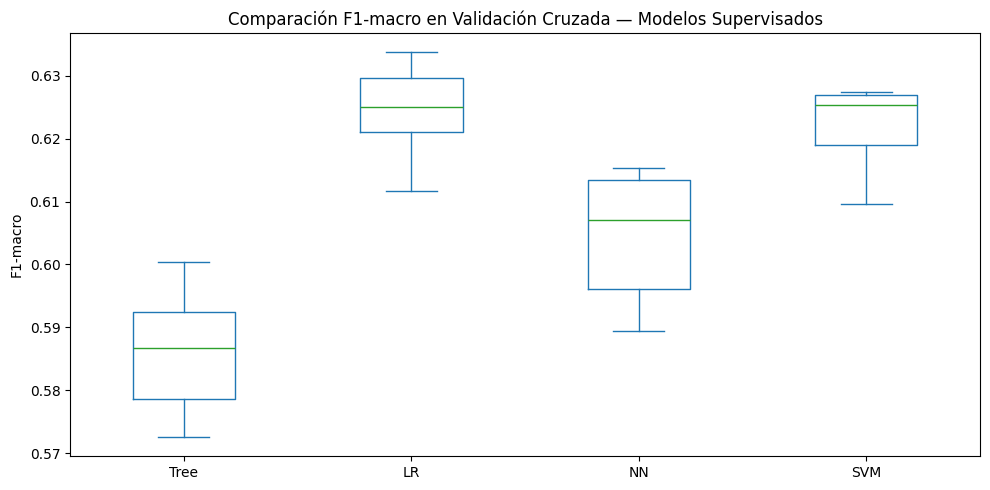

In [ ]:
# Boxplot comparación CV
comparacion_CV.plot(kind='box', figsize=(10, 5))
plt.title("Comparación F1-macro en Validación Cruzada — Modelos Supervisados")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

# **8. Ensambles**

**8.1 Random forest**

RANDOM FOREST

[Validación Cruzada]
Val F1-macro  : 0.6104 ± 0.0178
Train F1-macro: 0.6545
Val Accuracy  : 0.6390
Val Precision : 0.6070
Val Recall    : 0.6208

[Evaluación en Test 30%]
Test F1-macro : 0.5758
Test Accuracy : 0.6205

              precision    recall  f1-score   support

       Corta       0.80      0.70      0.75      1673
       Larga       0.50      0.67      0.57       535
       Media       0.40      0.41      0.41       791

    accuracy                           0.62      2999
   macro avg       0.57      0.59      0.58      2999
weighted avg       0.64      0.62      0.63      2999



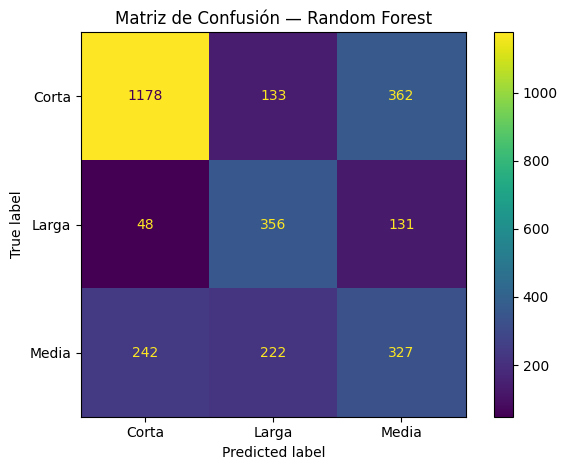

In [ ]:
# ============================================================
# ENSAMBLE 1 — RANDOM FOREST
# ============================================================
print("="*60)
print("RANDOM FOREST")
print("="*60)

model_rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=6,
    max_features='sqrt', class_weight='balanced', random_state=42
)

cv_res = cross_validate(model_rf, X_train_dum, Y_train_enc, cv=cv, scoring=scoring, return_train_score=True)

todos_los_modelos['RF'] = model_rf
resultados_cv['RF'] = {
    'val_f1':        cv_res['test_f1_macro'].mean(),
    'val_f1_std':    cv_res['test_f1_macro'].std(),
    'val_accuracy':  cv_res['test_accuracy'].mean(),
    'val_precision': cv_res['test_precision_macro'].mean(),
    'val_recall':    cv_res['test_recall_macro'].mean(),
    'train_f1':      cv_res['train_f1_macro'].mean(),
    'f1_por_fold':   cv_res['test_f1_macro']
}

print(f"\n[Validación Cruzada]")
print(f"Val F1-macro  : {resultados_cv['RF']['val_f1']:.4f} ± {resultados_cv['RF']['val_f1_std']:.4f}")
print(f"Train F1-macro: {resultados_cv['RF']['train_f1']:.4f}")
print(f"Val Accuracy  : {resultados_cv['RF']['val_accuracy']:.4f}")
print(f"Val Precision : {resultados_cv['RF']['val_precision']:.4f}")
print(f"Val Recall    : {resultados_cv['RF']['val_recall']:.4f}")

model_rf.fit(X_train_dum, Y_train_enc)
Y_pred_rf = model_rf.predict(X_test_dum)

print(f"\n[Evaluación en Test 30%]")
print(f"Test F1-macro : {f1_score(Y_test_enc, Y_pred_rf, average='macro'):.4f}")
print(f"Test Accuracy : {accuracy_score(Y_test_enc, Y_pred_rf):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_rf, target_names=le.classes_)}")

ConfusionMatrixDisplay.from_predictions(Y_test_enc, Y_pred_rf, display_labels=le.classes_)
plt.title("Matriz de Confusión — Random Forest")
plt.tight_layout()
plt.show()

comparacion_CV['RF'] = cv_res['test_f1_macro']

**8.2 XGBoost**

XGBOOST

[Validación Cruzada]
Val F1-macro  : 0.5826 ± 0.0093
Train F1-macro: 0.6248
Val Accuracy  : 0.6672
Val Precision : 0.6092
Val Recall    : 0.5941

[Evaluación en Test 30%]
Test F1-macro : 0.5601
Test Accuracy : 0.6602

              precision    recall  f1-score   support

       Corta       0.73      0.87      0.80      1673
       Larga       0.53      0.65      0.58       535
       Media       0.49      0.21      0.30       791

    accuracy                           0.66      2999
   macro avg       0.58      0.58      0.56      2999
weighted avg       0.63      0.66      0.63      2999



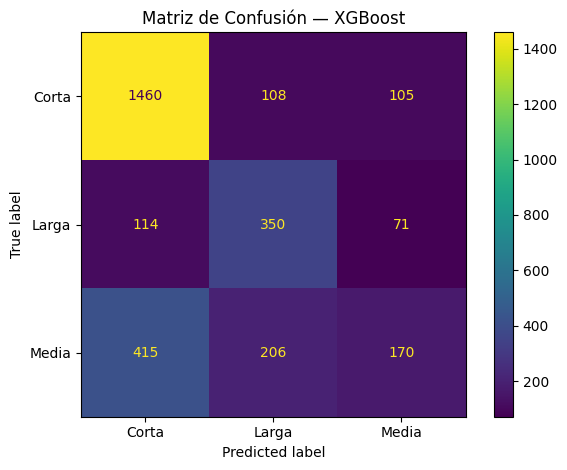

In [ ]:
# ============================================================
# ENSAMBLE 2 — XGBOOST
# ============================================================
print("="*60)
print("XGBOOST")
print("="*60)

model_xgb = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42
)

cv_res = cross_validate(model_xgb, X_train_dum, Y_train_enc, cv=cv, scoring=scoring, return_train_score=True)

todos_los_modelos['XGB'] = model_xgb
resultados_cv['XGB'] = {
    'val_f1':        cv_res['test_f1_macro'].mean(),
    'val_f1_std':    cv_res['test_f1_macro'].std(),
    'val_accuracy':  cv_res['test_accuracy'].mean(),
    'val_precision': cv_res['test_precision_macro'].mean(),
    'val_recall':    cv_res['test_recall_macro'].mean(),
    'train_f1':      cv_res['train_f1_macro'].mean(),
    'f1_por_fold':   cv_res['test_f1_macro']
}

print(f"\n[Validación Cruzada]")
print(f"Val F1-macro  : {resultados_cv['XGB']['val_f1']:.4f} ± {resultados_cv['XGB']['val_f1_std']:.4f}")
print(f"Train F1-macro: {resultados_cv['XGB']['train_f1']:.4f}")
print(f"Val Accuracy  : {resultados_cv['XGB']['val_accuracy']:.4f}")
print(f"Val Precision : {resultados_cv['XGB']['val_precision']:.4f}")
print(f"Val Recall    : {resultados_cv['XGB']['val_recall']:.4f}")

model_xgb.fit(X_train_dum, Y_train_enc)
Y_pred_xgb = model_xgb.predict(X_test_dum)

print(f"\n[Evaluación en Test 30%]")
print(f"Test F1-macro : {f1_score(Y_test_enc, Y_pred_xgb, average='macro'):.4f}")
print(f"Test Accuracy : {accuracy_score(Y_test_enc, Y_pred_xgb):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_xgb, target_names=le.classes_)}")

ConfusionMatrixDisplay.from_predictions(Y_test_enc, Y_pred_xgb, display_labels=le.classes_)
plt.title("Matriz de Confusión — XGBoost")
plt.tight_layout()
plt.show()

comparacion_CV['XGB'] = cv_res['test_f1_macro']

**8.3 Gradient Boosting**

GRADIENT BOOSTING

[Validación Cruzada]
Val F1-macro  : 0.5852 ± 0.0107
Train F1-macro: 0.6270
Val Accuracy  : 0.6642
Val Precision : 0.6048
Val Recall    : 0.5930

[Evaluación en Test 30%]
Test F1-macro : 0.5614
Test Accuracy : 0.6579

              precision    recall  f1-score   support

       Corta       0.74      0.87      0.80      1673
       Larga       0.54      0.64      0.58       535
       Media       0.46      0.23      0.30       791

    accuracy                           0.66      2999
   macro avg       0.58      0.58      0.56      2999
weighted avg       0.63      0.66      0.63      2999



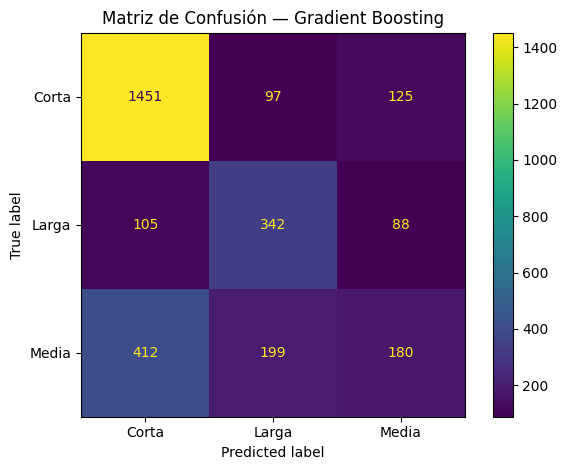

In [ ]:
# ============================================================
# ENSAMBLE 3 — GRADIENT BOOSTING
# ============================================================
print("="*60)
print("GRADIENT BOOSTING")
print("="*60)

model_gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.9, min_samples_leaf=5, random_state=42
)

cv_res = cross_validate(model_gb, X_train_dum, Y_train_enc, cv=cv, scoring=scoring, return_train_score=True)

todos_los_modelos['GB'] = model_gb
resultados_cv['GB'] = {
    'val_f1':        cv_res['test_f1_macro'].mean(),
    'val_f1_std':    cv_res['test_f1_macro'].std(),
    'val_accuracy':  cv_res['test_accuracy'].mean(),
    'val_precision': cv_res['test_precision_macro'].mean(),
    'val_recall':    cv_res['test_recall_macro'].mean(),
    'train_f1':      cv_res['train_f1_macro'].mean(),
    'f1_por_fold':   cv_res['test_f1_macro']
}

print(f"\n[Validación Cruzada]")
print(f"Val F1-macro  : {resultados_cv['GB']['val_f1']:.4f} ± {resultados_cv['GB']['val_f1_std']:.4f}")
print(f"Train F1-macro: {resultados_cv['GB']['train_f1']:.4f}")
print(f"Val Accuracy  : {resultados_cv['GB']['val_accuracy']:.4f}")
print(f"Val Precision : {resultados_cv['GB']['val_precision']:.4f}")
print(f"Val Recall    : {resultados_cv['GB']['val_recall']:.4f}")

model_gb.fit(X_train_dum, Y_train_enc)
Y_pred_gb = model_gb.predict(X_test_dum)

print(f"\n[Evaluación en Test 30%]")
print(f"Test F1-macro : {f1_score(Y_test_enc, Y_pred_gb, average='macro'):.4f}")
print(f"Test Accuracy : {accuracy_score(Y_test_enc, Y_pred_gb):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_gb, target_names=le.classes_)}")

ConfusionMatrixDisplay.from_predictions(Y_test_enc, Y_pred_gb, display_labels=le.classes_)
plt.title("Matriz de Confusión — Gradient Boosting")
plt.tight_layout()
plt.show()

comparacion_CV['GB'] = cv_res['test_f1_macro']

**8.4 Resumen**

In [ ]:
# ─────────────────────────────────────────────
# RESUMEN MODELOS DE ENSAMBLE
# ─────────────────────────────────────────────

resumen_ensamble = pd.DataFrame({
    modelo: {
        'CV F1-macro':    round(v['val_f1'], 4),
        'CV F1-std':      round(v['val_f1_std'], 4),
        'CV Accuracy':    round(v['val_accuracy'], 4),
        'CV Precision':   round(v['val_precision'], 4),
        'CV Recall':      round(v['val_recall'], 4),
        'Train F1-macro': round(v['train_f1'], 4),
    }
    for modelo, v in resultados_cv.items()
    if modelo in ['RF', 'XGB', 'GB']
}).T

print("=== RESUMEN MODELOS DE ENSAMBLE ===")
print(resumen_ensamble.to_string())

=== RESUMEN MODELOS DE ENSAMBLE ===
     CV F1-macro  CV F1-std  CV Accuracy  CV Precision  CV Recall  Train F1-macro
RF        0.6104     0.0178       0.6390        0.6070     0.6208          0.6545
XGB       0.5826     0.0093       0.6672        0.6092     0.5941          0.6248
GB        0.5852     0.0107       0.6642        0.6048     0.5930          0.6270


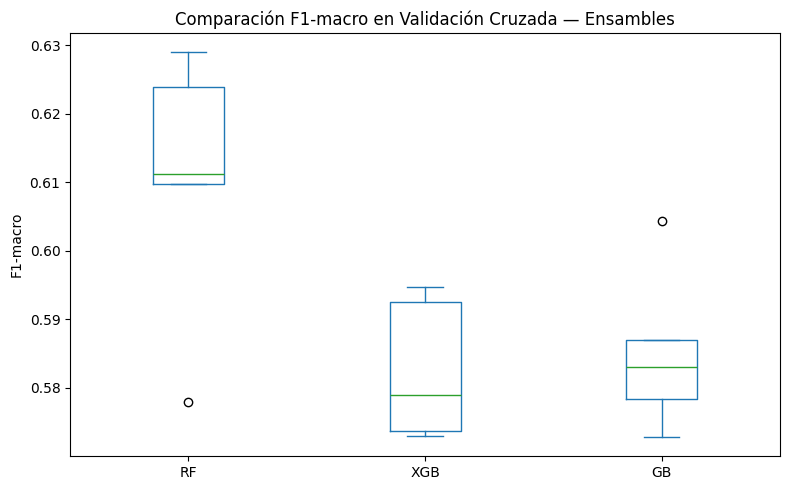

In [ ]:
# Boxplot ensambles
comparacion_CV[['RF', 'XGB', 'GB']].plot(kind='box', figsize=(8, 5))
plt.title("Comparación F1-macro en Validación Cruzada — Ensambles")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

# **9. Resumen de todos los modelos**

**9.1 Resumen Métricas**

In [ ]:
# ─────────────────────────────────────────────
# RESUMEN TODOS LOS MODELOS
# ─────────────────────────────────────────────

resumen_todos = pd.DataFrame({
    modelo: {
        'CV F1-macro':    round(v['val_f1'], 4),
        'CV F1-std':      round(v['val_f1_std'], 4),
        'CV Accuracy':    round(v['val_accuracy'], 4),
        'CV Precision':   round(v['val_precision'], 4),
        'CV Recall':      round(v['val_recall'], 4),
        'Train F1-macro': round(v['train_f1'], 4),
    }
    for modelo, v in resultados_cv.items()
}).T

print("=== RESUMEN TODOS LOS MODELOS ===")
print(resumen_todos.to_string())

=== RESUMEN TODOS LOS MODELOS ===
      CV F1-macro  CV F1-std  CV Accuracy  CV Precision  CV Recall  Train F1-macro
Tree       0.5862     0.0098       0.6106        0.5891     0.5963          0.6277
LR         0.6242     0.0076       0.6485        0.6230     0.6333          0.6645
NN         0.6043     0.0100       0.6733        0.6185     0.6098          0.6460
SVM        0.6216     0.0068       0.6420        0.6245     0.6288          0.6644
RF         0.6104     0.0178       0.6390        0.6070     0.6208          0.6545
XGB        0.5826     0.0093       0.6672        0.6092     0.5941          0.6248
GB         0.5852     0.0107       0.6642        0.6048     0.5930          0.6270


**9.2 Boxplot**

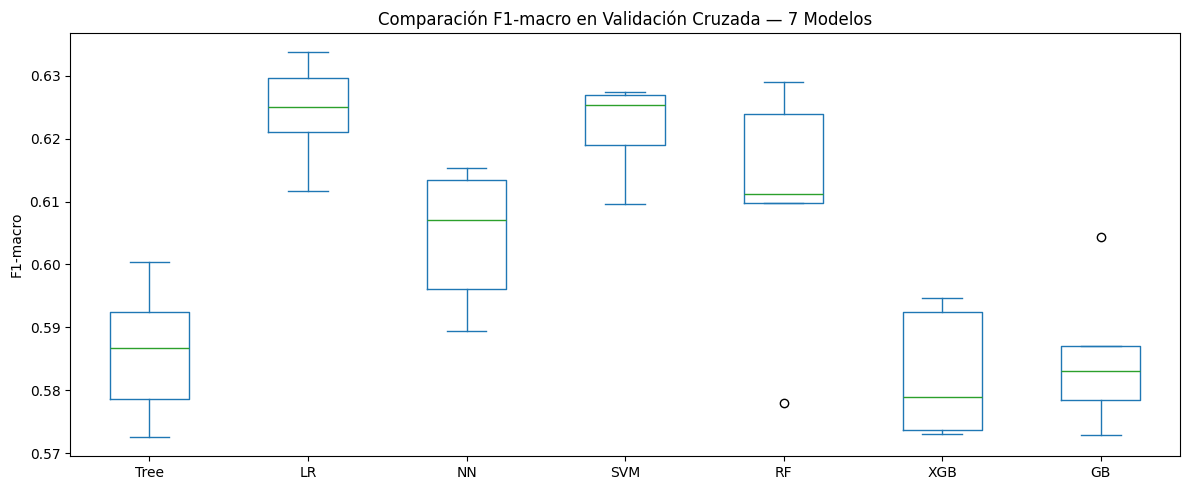

In [ ]:
# Boxplot todos los modelos
comparacion_CV.plot(kind='box', figsize=(12, 5))
plt.title("Comparación F1-macro en Validación Cruzada — 7 Modelos")
plt.ylabel("F1-macro")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**9.3 Curva ROC**

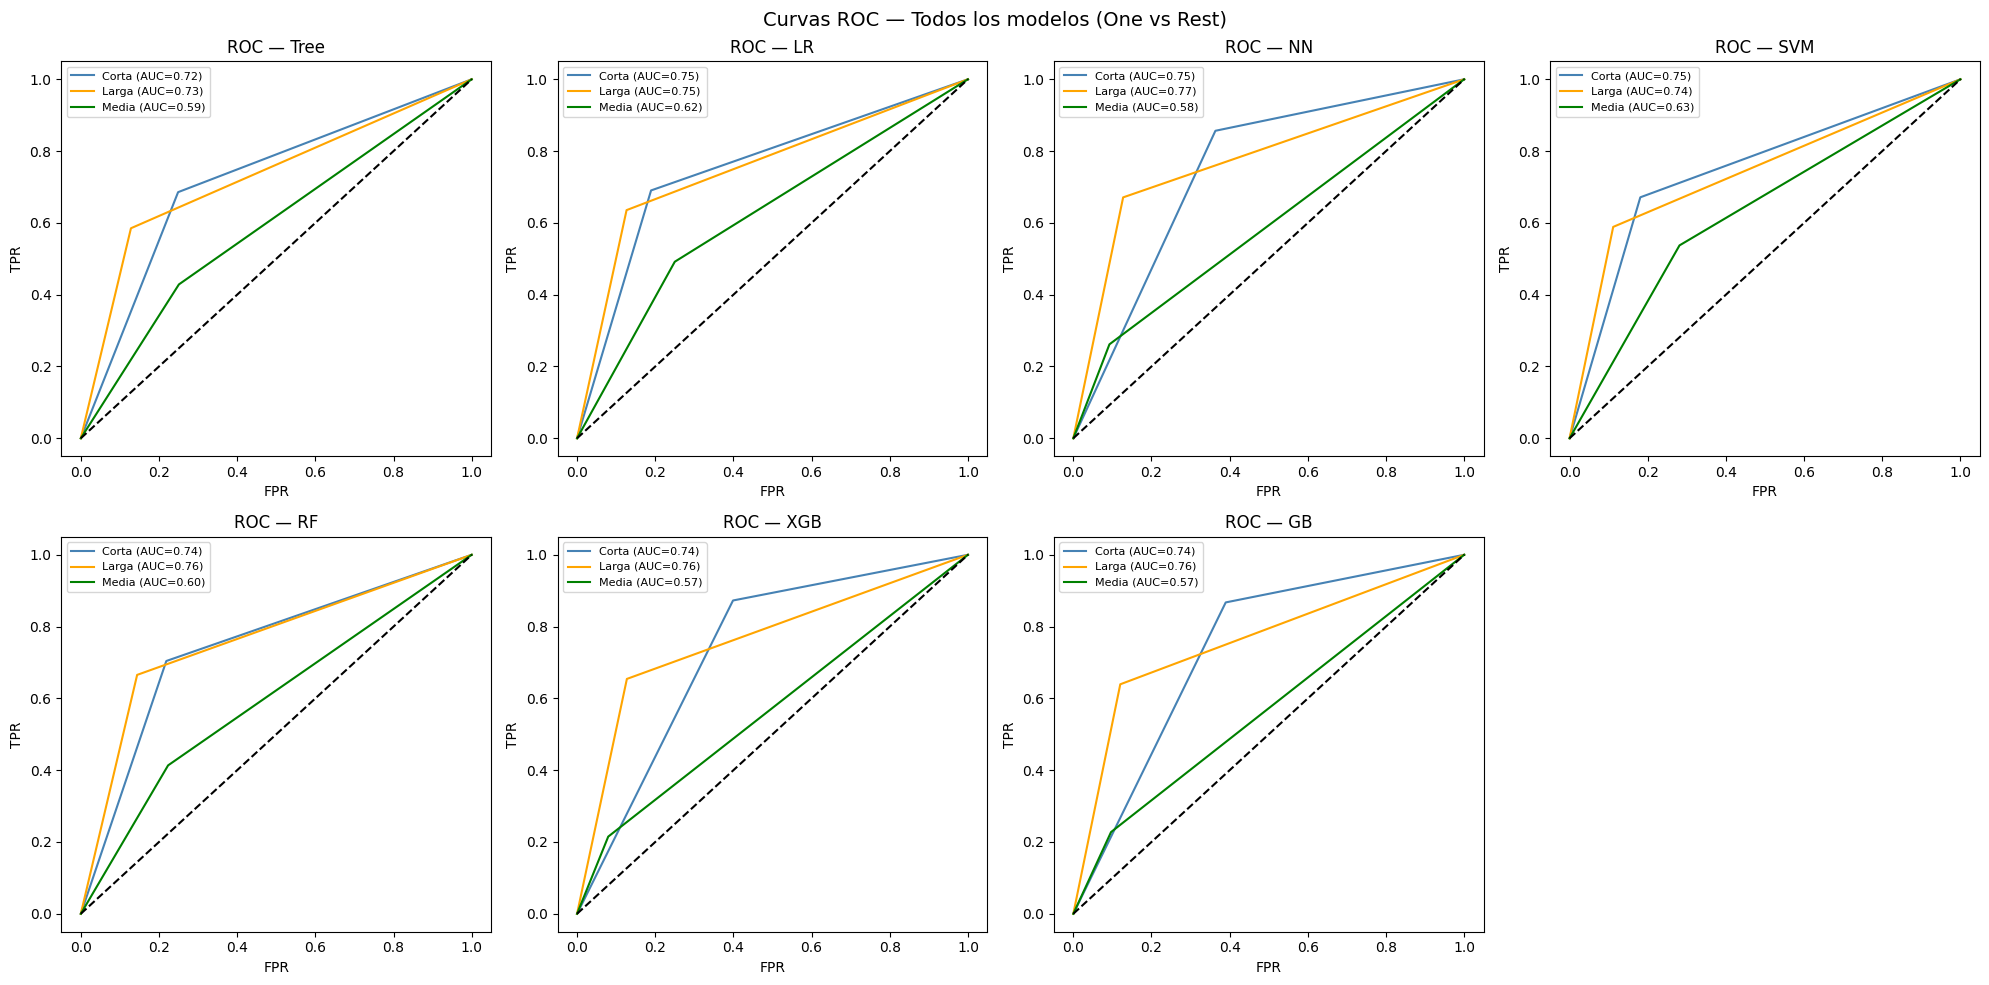

In [ ]:
# ─────────────────────────────────────────────
# CURVAS ROC — todos los modelos (One vs Rest)
# ─────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar el target para OvR
Y_test_bin = label_binarize(Y_test_enc, classes=[0, 1, 2])
clases = le.classes_
colores = ['steelblue', 'orange', 'green']

modelos_pred = {
    'Tree': (model_tree, Y_pred_tree),
    'LR':   (model_lr,   Y_pred_lr),
    'NN':   (model_rn,   Y_pred_rn),
    'SVM':  (model_svm,  Y_pred_svm),
    'RF':   (model_rf,   Y_pred_rf),
    'XGB':  (model_xgb,  Y_pred_xgb),
    'GB':   (model_gb,   Y_pred_gb),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (nombre, (modelo, y_pred)) in enumerate(modelos_pred.items()):
    # Binarizar predicciones para OvR
    y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2])

    for i, (clase, color) in enumerate(zip(clases, colores)):
        fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_pred_bin[:, i])
        roc_auc = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, color=color, label=f'{clase} (AUC={roc_auc:.2f})')

    axes[idx].plot([0, 1], [0, 1], 'k--')
    axes[idx].set_title(f'ROC — {nombre}')
    axes[idx].set_xlabel('FPR')
    axes[idx].set_ylabel('TPR')
    axes[idx].legend(fontsize=8)

# Ocultar el último subplot vacío
axes[-1].set_visible(False)

plt.suptitle("Curvas ROC — Todos los modelos (One vs Rest)", fontsize=14)
plt.tight_layout()
plt.show()

# **10. Selección estadística**

**10.1 Shapiro-Wilk para verificar distribución normal**

In [ ]:
print("=== Prueba de Shapiro-Wilk (Normalidad) ===\n")
for modelo in comparacion_CV.columns:
    stat, p = stats.shapiro(comparacion_CV[modelo])
    resultado = "Normal" if p > 0.05 else "No normal"
    print(f"{modelo}: stat={stat:.4f}, p={p:.4f} → {resultado}")

=== Prueba de Shapiro-Wilk (Normalidad) ===

Tree: stat=0.9847, p=0.9581 → Normal
LR: stat=0.9724, p=0.8903 → Normal
NN: stat=0.9145, p=0.4950 → Normal
SVM: stat=0.8366, p=0.1556 → Normal
RF: stat=0.8811, p=0.3144 → Normal
XGB: stat=0.8369, p=0.1566 → Normal
GB: stat=0.9242, p=0.5572 → Normal


**10.2 Levene (Homogeneidad de varianzas)**

In [ ]:
print("=== Prueba de Levene (Homogeneidad de Varianzas) ===\n")

stat, p = stats.levene(
    comparacion_CV['Tree'],
    comparacion_CV['LR'],
    comparacion_CV['NN'],
    comparacion_CV['SVM'],
    comparacion_CV['RF'],
    comparacion_CV['XGB'],
    comparacion_CV['GB']
)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-value: {p:.4f}")

if p > 0.05:
    print("\n Varianzas homogéneas → procedemos con ANOVA")
else:
    print("\n Varianzas no homogéneas → usar Welch ANOVA")

=== Prueba de Levene (Homogeneidad de Varianzas) ===

Estadístico de Levene: 0.4945
p-value: 0.8069

 Varianzas homogéneas → procedemos con ANOVA


**10.3 ANOVA**

In [ ]:
print("=== ANOVA de un factor ===\n")

stat, p = stats.f_oneway(
    comparacion_CV['Tree'],
    comparacion_CV['LR'],
    comparacion_CV['NN'],
    comparacion_CV['SVM'],
    comparacion_CV['RF'],
    comparacion_CV['XGB'],
    comparacion_CV['GB']
)

print(f"Estadístico F: {stat:.4f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("\n Hay diferencia significativa entre al menos dos modelos")
    print("→ Procedemos con Tukey HSD para identificar cuáles")
else:
    print("\n No hay diferencia significativa entre los modelos")
    print("→ Elegir por criterios secundarios: F1, recall, AUC")

=== ANOVA de un factor ===

Estadístico F: 10.6719
p-value: 0.0000

 Hay diferencia significativa entre al menos dos modelos
→ Procedemos con Tukey HSD para identificar cuáles


**10.4 TUKEY HSD**

In [ ]:
print("=== Prueba de Tukey HSD ===\n")

scores_largo = comparacion_CV.melt(var_name='Modelo', value_name='F1_Score')

tukey = pairwise_tukeyhsd(
    endog=scores_largo['F1_Score'],
    groups=scores_largo['Modelo'],
    alpha=0.05
)

print(tukey)

=== Prueba de Tukey HSD ===

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    GB     LR   0.0391 0.0004  0.0148  0.0633   True
    GB     NN   0.0191 0.1961 -0.0051  0.0434  False
    GB     RF   0.0252 0.0371   0.001  0.0495   True
    GB    SVM   0.0365 0.0009  0.0123  0.0607   True
    GB   Tree    0.001    1.0 -0.0232  0.0252  False
    GB    XGB  -0.0026 0.9999 -0.0268  0.0216  False
    LR     NN  -0.0199 0.1609 -0.0442  0.0043  False
    LR     RF  -0.0138 0.5518 -0.0381  0.0104  False
    LR    SVM  -0.0026 0.9999 -0.0268  0.0216  False
    LR   Tree  -0.0381 0.0005 -0.0623 -0.0138   True
    LR    XGB  -0.0417 0.0001 -0.0659 -0.0174   True
    NN     RF   0.0061 0.9831 -0.0181  0.0303  False
    NN    SVM   0.0174 0.2918 -0.0069  0.0416  False
    NN   Tree  -0.0181 0.2473 -0.0424  0.0061  False
    NN    XGB  -0.0217 0.1013  -0.046  0.0025  False
    RF    SVM   0

**10.5 Selección TOP 3**

In [ ]:
top3 = ['LR', 'SVM', 'RF']

print("=== TOP 3 MODELOS SELECCIONADOS ===\n")
resumen_top3 = pd.DataFrame({
    modelo: {
        'CV F1-macro':    round(resultados_cv[modelo]['val_f1'], 4),
        'CV Recall':      round(resultados_cv[modelo]['val_recall'], 4),
        'Train F1-macro': round(resultados_cv[modelo]['train_f1'], 4),
    }
    for modelo in top3
}).T

print(resumen_top3.to_string())

=== TOP 3 MODELOS SELECCIONADOS ===

     CV F1-macro  CV Recall  Train F1-macro
LR        0.6242     0.6333          0.6645
SVM       0.6216     0.6288          0.6644
RF        0.6104     0.6208          0.6545


# **11. Hiperparametrización**

**11.1 GRIDSEARCH**

**11.1.1 Regresión Logística**

In [ ]:
from sklearn.model_selection import GridSearchCV
# ============================================================
# GRIDSEARCH — REGRESIÓN LOGÍSTICA
# ============================================================
print("="*60)
print("GRIDSEARCH — REGRESIÓN LOGÍSTICA")
print("="*60)

param_grid_lr = {
    'C':       [0.01, 0.1, 0.5, 1.0, 5.0],
    'solver':  ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

grid_lr = GridSearchCV(
    LogisticRegression(multi_class='multinomial', class_weight='balanced', random_state=42),
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_dum, Y_train_enc)

print(f"\nMejores parámetros: {grid_lr.best_params_}")
print(f"Mejor F1-macro CV: {grid_lr.best_score_:.4f}")

Y_pred_grid_lr = grid_lr.predict(X_test_dum)
print(f"Test F1-macro: {f1_score(Y_test_enc, Y_pred_grid_lr, average='macro'):.4f}")
print(f"Test Accuracy: {accuracy_score(Y_test_enc, Y_pred_grid_lr):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_grid_lr, target_names=le.classes_)}")

GRIDSEARCH — REGRESIÓN LOGÍSTICA
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros: {'C': 0.5, 'max_iter': 500, 'solver': 'lbfgs'}
Mejor F1-macro CV: 0.6242
Test F1-macro: 0.5908
Test Accuracy: 0.6282

              precision    recall  f1-score   support

       Corta       0.82      0.69      0.75      1673
       Larga       0.52      0.64      0.57       535
       Media       0.41      0.49      0.45       791

    accuracy                           0.63      2999
   macro avg       0.59      0.61      0.59      2999
weighted avg       0.66      0.63      0.64      2999



**11.1.2 SVM**

In [ ]:
# ============================================================
# GRIDSEARCH — SVM
# ============================================================
print("="*60)
print("GRIDSEARCH — SVM")
print("="*60)

param_grid_svm = {
    'C':      [0.1, 0.3, 0.5, 1.0, 2.0],
    'kernel': ['linear', 'rbf'],
    'gamma':  ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid_svm,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_dum, Y_train_enc)

print(f"\nMejores parámetros: {grid_svm.best_params_}")
print(f"Mejor F1-macro CV: {grid_svm.best_score_:.4f}")

Y_pred_grid_svm = grid_svm.predict(X_test_dum)
print(f"Test F1-macro: {f1_score(Y_test_enc, Y_pred_grid_svm, average='macro'):.4f}")
print(f"Test Accuracy: {accuracy_score(Y_test_enc, Y_pred_grid_svm):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_grid_svm, target_names=le.classes_)}")

GRIDSEARCH — SVM
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1-macro CV: 0.6389
Test F1-macro: 0.5939
Test Accuracy: 0.6272

              precision    recall  f1-score   support

       Corta       0.82      0.68      0.74      1673
       Larga       0.55      0.62      0.58       535
       Media       0.41      0.51      0.45       791

    accuracy                           0.63      2999
   macro avg       0.59      0.61      0.59      2999
weighted avg       0.66      0.63      0.64      2999



**11.1..3 Random Forest**

In [ ]:
# ============================================================
# GRIDSEARCH — RANDOM FOREST
# ============================================================
print("="*60)
print("GRIDSEARCH — RANDOM FOREST")
print("="*60)

param_grid_rf = {
    'n_estimators':   [100, 200, 300],
    'max_depth':      [None, 20, 30],
    'min_samples_leaf': [4, 6, 8],
    'max_features':   ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_dum, Y_train_enc)

print(f"\nMejores parámetros: {grid_rf.best_params_}")
print(f"Mejor F1-macro CV: {grid_rf.best_score_:.4f}")

Y_pred_grid_rf = grid_rf.predict(X_test_dum)
print(f"Test F1-macro: {f1_score(Y_test_enc, Y_pred_grid_rf, average='macro'):.4f}")
print(f"Test Accuracy: {accuracy_score(Y_test_enc, Y_pred_grid_rf):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_grid_rf, target_names=le.classes_)}")

GRIDSEARCH — RANDOM FOREST
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 300}
Mejor F1-macro CV: 0.6195
Test F1-macro: 0.5769
Test Accuracy: 0.6205

              precision    recall  f1-score   support

       Corta       0.80      0.70      0.75      1673
       Larga       0.51      0.65      0.57       535
       Media       0.40      0.42      0.41       791

    accuracy                           0.62      2999
   macro avg       0.57      0.59      0.58      2999
weighted avg       0.64      0.62      0.63      2999



**11.2 Optimización Bayesiana**

In [ ]:
# ============================================================
# OPTIMIZACIÓN BAYESIANA — SVM (mejor modelo)
# ============================================================
print("="*60)
print("OPTIMIZACIÓN BAYESIANA — SVM")
print("="*60)

!pip install scikit-optimize -q
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

param_bayes_svm = {
    'C':      Real(0.01, 10.0, prior='log-uniform'),
    'gamma':  Categorical(['scale', 'auto']),
    'kernel': Categorical(['linear', 'rbf', 'poly'])
}

bayes_svm = BayesSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_bayes_svm,
    n_iter=30,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

bayes_svm.fit(X_train_dum, Y_train_enc)

print(f"\nMejores parámetros: {bayes_svm.best_params_}")
print(f"Mejor F1-macro CV: {bayes_svm.best_score_:.4f}")

Y_pred_bayes = bayes_svm.predict(X_test_dum)
print(f"Test F1-macro: {f1_score(Y_test_enc, Y_pred_bayes, average='macro'):.4f}")
print(f"Test Accuracy: {accuracy_score(Y_test_enc, Y_pred_bayes):.4f}")
print(f"\n{classification_report(Y_test_enc, Y_pred_bayes, target_names=le.classes_)}")

OPTIMIZACIÓN BAYESIANA — SVM
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fittin

# **12. Pipeline**

**12.1 Imports y configuración**

In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTEN
import matplotlib.pyplot as plt

**12.2 Definición y exportación de clases**

In [ ]:
clases_codigo = """import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class LimpiezaInicial(BaseEstimator, TransformerMixin):
    ELIMINAR = [
        "Operating Certificate Number", "Facility Id", "Facility Name",
        "Zip Code - 3 digits", "Discharge Year", "Abortion Edit Indicator",
        "Attending Provider License Number", "Operating Provider License Number",
        "Other Provider License Number", "CCS Diagnosis Description",
        "CCS Procedure Description", "APR DRG Description", "APR MDC Description",
        "APR Severity of Illness Description", "Payment Typology 2",
        "Payment Typology 3", "Patient Disposition", "Total Charges", "Total Costs",
        "Ethnicity", "Gender", "APR Medical Surgical Description",
        "Hospital County", "Race", "Birth Weight", "Emergency Department Indicator",
        "Health Service Area"
    ]
    CATEGORICAS = [
        "Age Group", "Type of Admission", "APR Risk of Mortality",
        "Payment Typology 1", "APR MDC Code", "APR Severity of Illness Code",
        "APR DRG Code", "CCS Diagnosis Code", "CCS Procedure Code"
    ]
    def fit(self, X, y=None): return self
    def transform(self, X):
        df = X.copy()
        df = df.drop(columns=[c for c in self.ELIMINAR if c in df.columns])
        for col in self.CATEGORICAS:
            if col in df.columns:
                df[col] = df[col].astype("category")
        return df

class ImputacionNulos(BaseEstimator, TransformerMixin):
    IMPUTAR_MODA = ["APR Risk of Mortality"]
    def fit(self, X, y=None):
        self.modas_ = {}
        for col in self.IMPUTAR_MODA:
            if col in X.columns:
                self.modas_[col] = X[col].mode()[0]
        return self
    def transform(self, X):
        df = X.copy()
        for col, moda in self.modas_.items():
            if col in df.columns:
                df[col] = df[col].fillna(moda)
                if hasattr(df[col], "cat"):
                    df[col] = df[col].cat.remove_unused_categories()
        return df

class AgrupacionCCS(BaseEstimator, TransformerMixin):
    DX_GRUPOS = {
        **{c: "Infecciosas"            for c in range(1, 11)},
        **{c: "Cancer"                 for c in range(11, 46)},
        **{c: "Neoplasias_benignas"    for c in range(46, 48)},
        **{c: "Endocrinas_metabolicas" for c in range(48, 65)},
        **{c: "Mentales"               for c in list(range(650, 664)) + [670]},
        **{c: "Nervioso_sensorial"     for c in range(76, 96)},
        **{c: "Circulatorio"           for c in range(96, 122)},
        **{c: "Respiratorio"           for c in range(122, 135)},
        **{c: "Digestivo"              for c in range(135, 156)},
        **{c: "Genitourinario"         for c in range(156, 176)},
        **{c: "Embarazo_parto"         for c in range(176, 197)},
        **{c: "Piel"                   for c in range(197, 201)},
        **{c: "Musculoesqueletico"     for c in range(201, 213)},
        **{c: "Congenitas"             for c in range(213, 218)},
        **{c: "Perinatales"            for c in range(218, 225)},
        **{c: "Sintomas_mal_definidos" for c in range(225, 245)},
        **{c: "Lesiones"               for c in range(245, 260)},
        917: "Especiales"
    }
    PR_GRUPOS = {
        0: "Sin_procedimiento",
        **{c: "Sistema_nervioso"        for c in range(1, 10)},
        **{c: "Sistema_endocrino"       for c in range(10, 13)},
        **{c: "Ojos_oidos"              for c in range(13, 22)},
        **{c: "Cardiovascular"          for c in range(22, 48)},
        **{c: "Respiratorio"            for c in range(48, 56)},
        **{c: "Digestivo"               for c in range(56, 84)},
        **{c: "Urinario_renal"          for c in range(84, 101)},
        **{c: "Ginecologia_obstetricia" for c in range(101, 140)},
        **{c: "Musculoesqueletico"      for c in range(140, 168)},
        **{c: "Tegumentario"            for c in range(168, 176)},
        **{c: "Hematologia_inmunologia" for c in range(176, 182)},
        **{c: "Diagnostico"             for c in range(182, 210)},
        **{c: "Terapeutico_miscelaneo"  for c in range(210, 232)},
        999: "Otros"
    }
    def fit(self, X, y=None): return self
    def transform(self, X):
        df = X.copy()
        if "CCS Diagnosis Code" in df.columns:
            df["CCS_DX_Grupo"] = df["CCS Diagnosis Code"].astype(int).map(
                self.DX_GRUPOS).fillna("Otros").astype("category")
            df = df.drop(columns=["CCS Diagnosis Code"])
        if "CCS Procedure Code" in df.columns:
            df["CCS_PR_Grupo"] = df["CCS Procedure Code"].astype(int).map(
                self.PR_GRUPOS).fillna("Otros").astype("category")
            df = df.drop(columns=["CCS Procedure Code"])
        return df
"""

# Exportar a archivo
with open("transformadores.py", "w") as f:
    f.write(clases_codigo)

# Importar desde el archivo para que el pickle sea portable
import importlib, sys
if "transformadores" in sys.modules:
    del sys.modules["transformadores"]

from transformadores import LimpiezaInicial, ImputacionNulos, AgrupacionCCS

print("Clases exportadas a transformadores.py e importadas correctamente")

Clases exportadas a transformadores.py e importadas correctamente


**12.3 Preparar X e Y**

In [ ]:
def categorizar_los(dias):
    if pd.isna(dias):  return np.nan
    elif dias <= 3:    return "Corta"
    elif dias <= 7:    return "Media"
    else:              return "Larga"

# Cargar datos crudos
df_crudo = pd.read_csv("muestra_sparcs_10000.csv")

# Preprocesador histórico
prep_historico = Pipeline(steps=[
    ("limpieza", LimpiezaInicial()),
    ("nulos",    ImputacionNulos()),
    ("ccs",      AgrupacionCCS()),
])

df_prep = prep_historico.fit_transform(df_crudo)

# Crear target
df_prep["Length of Stay"] = pd.to_numeric(df_crudo["Length of Stay"], errors="coerce")
df_prep["los_categoria"]  = df_prep["Length of Stay"].apply(categorizar_los).astype("category")
df_prep = df_prep.drop(columns=["Length of Stay"])
df_prep = df_prep.dropna(subset=["los_categoria"])

# Separar X e Y
variables_modelo = [
    "Age Group", "Type of Admission", "APR DRG Code", "APR MDC Code",
    "APR Severity of Illness Code", "APR Risk of Mortality",
    "Payment Typology 1", "CCS_DX_Grupo", "CCS_PR_Grupo"
]
objetivo = "los_categoria"

X = df_prep[variables_modelo].copy()
Y = df_prep[objetivo].copy()

X_train_pipe, X_test_pipe, Y_train_pipe, Y_test_pipe = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y
)

print(f"Train: {X_train_pipe.shape[0]} | Test: {X_test_pipe.shape[0]}")
print(f"\nDistribución train:")
print(Y_train_pipe.value_counts())

Train: 6995 | Test: 2999

Distribución train:
los_categoria
Corta    3900
Media    1846
Larga    1249
Name: count, dtype: int64


**12.4 Pipeline completo**

In [ ]:
pipeline_final = ImbPipeline(steps=[
    ("balanceo", SMOTEN(
        sampling_strategy={"Larga": 1950},
        k_neighbors=5,
        random_state=42
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )),
    ("modelo", SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=42
    ))
])

print("Pipeline de despliegue:")
for nombre, paso in pipeline_final.steps:
    print(f"  → {nombre}: {type(paso).__name__}")

Pipeline de despliegue:
  → balanceo: SMOTEN
  → onehot: OneHotEncoder
  → modelo: SVC


**12.5 Entrenamiento y evaluación**

Pipeline entrenado.

=== Evaluación final en test 30% ===
F1-macro  : 0.5939
Accuracy  : 0.6272
Precision : 0.5917
Recall    : 0.6055

              precision    recall  f1-score   support

       Corta       0.82      0.68      0.74      1673
       Larga       0.55      0.62      0.58       535
       Media       0.41      0.51      0.45       791

    accuracy                           0.63      2999
   macro avg       0.59      0.61      0.59      2999
weighted avg       0.66      0.63      0.64      2999



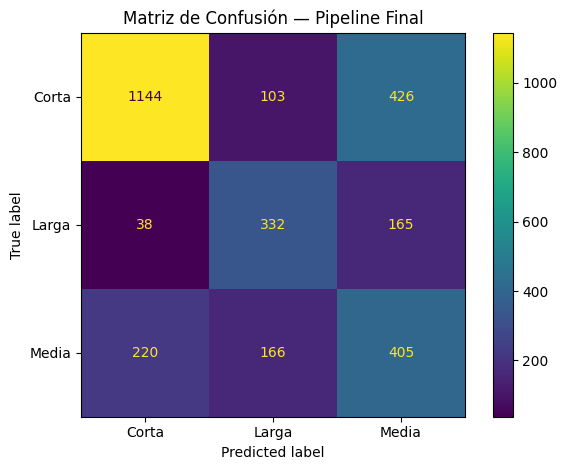

In [ ]:
pipeline_final.fit(X_train_pipe, Y_train_pipe)
print("Pipeline entrenado.\n")

Y_pred_pipe = pipeline_final.predict(X_test_pipe)

print("=== Evaluación final en test 30% ===")
print(f"F1-macro  : {f1_score(Y_test_pipe, Y_pred_pipe, average='macro'):.4f}")
print(f"Accuracy  : {accuracy_score(Y_test_pipe, Y_pred_pipe):.4f}")
print(f"Precision : {precision_score(Y_test_pipe, Y_pred_pipe, average='macro'):.4f}")
print(f"Recall    : {recall_score(Y_test_pipe, Y_pred_pipe, average='macro'):.4f}")
print(f"\n{classification_report(Y_test_pipe, Y_pred_pipe)}")

ConfusionMatrixDisplay.from_predictions(
    Y_test_pipe, Y_pred_pipe,
    display_labels=pipeline_final.classes_
)
plt.title("Matriz de Confusión — Pipeline Final")
plt.tight_layout()
plt.show()

**12.6 Guardar**

In [ ]:
artefacto_final = {
    "pipeline":          pipeline_final,      # pipeline de despliegue
    "preprocesador":     prep_historico,      # para transformar nuevos datos
    "variables_modelo":  variables_modelo,
    "objetivo":          objetivo,
    "clases":            list(pipeline_final.classes_),
    "version":           "1.0.0"
}

joblib.dump(artefacto_final, "modelo_final_pipeline.pkl")
print("Modelo guardado: modelo_final_pipeline.pkl")
print(f"Clases:    {list(pipeline_final.classes_)}")
print(f"Variables: {variables_modelo}")

Modelo guardado: modelo_final_pipeline.pkl
Clases:    ['Corta', 'Larga', 'Media']
Variables: ['Age Group', 'Type of Admission', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'Payment Typology 1', 'CCS_DX_Grupo', 'CCS_PR_Grupo']
